In [1]:
import os
os.getcwd()
os.chdir('/Volumes/MacBack/GenzelLab/REMPhasicTonic')
os.getcwd()

'/Volumes/MacBack/GenzelLab/REMPhasicTonic'

In [2]:
os.path.abspath('')

'/Volumes/MacBack/GenzelLab/REMPhasicTonic'

In [2]:
# uploading the important libraries and functions that will be used in the analysis 
config = {}
config = {'basedir': '/Volumes/MacBack/GenzelLab/VitorCode/QinnonThetaFreq/dlt2/aquinn/ThetaShapeExample/data_dist',
          'figdir': None,
          'datadir': None,
          'analysisdir': '/Volumes/MacBack/GenzelLab/VitorCode/QinnonThetaFreq/dlt2/aquinn/ThetaShapeExample/data_dist'}
config['1col_width'] = 85
config['2col_width'] = 114
config['3col_width'] = 174
config['fontname'] = 'Helvetica'

config['recordings'] = ['mdm81-2311-0128_2',
                        'mdm81-2311-0128_5',
                        'mdm90-1901-0127_2',
                        'mdm90-1901-0127_5',
                        'mdm96-1806-0121_2',
                        'mdm96-1806-0121_6']

config['tetrode_inds'] = [25, 25, 9, 9, 33, 33]


import emd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import signal, stats, ndimage
from scipy import ndimage, interpolate
import sails
import h5py
import logging 
import pandas as pd
import glmtools as glm
from scipy import stats
from matplotlib.colors import ListedColormap
import scipy.io
matplotlib.rc('font', serif=config['fontname'])



def my_range(x):
    return x.max() - x.min()

def compute_range(x):
    return x.max() - x.min()


def asc2desc(x):
    """Ascending to Descending ratio ( A / A+D )."""
    pt = emd.cycles.cf_peak_sample(x, interp=True)
    tt = emd.cycles.cf_trough_sample(x, interp=True)
    if (pt is None) or (tt is None):
        return np.nan
    asc = pt + (len(x) - tt)
    desc = tt - pt
    return asc / len(x)

def peak2trough(x):
    """Peak to trough ratio ( P / P+T )."""
    des = emd.cycles.cf_descending_zero_sample(x, interp=True)
    if des is None:
        return np.nan
    return des / len(x)

def decorate_ax(ax):
    for tag in ['top', 'right']:
        ax.spines[tag].set_visible(False)
        
def load_tracking(whl_path, new_len, smoothing=1):
    """Load position data from .whl file"""
    track = np.genfromtxt( whl_path )
    track[track<0] = np.nan
    if smoothing is not None:
            track = ndimage.filters.gaussian_filter1d(track, smoothing, axis=0)

    pixels2bins = 37 / (np.nanmax(track[:,0])-np.nanmin(track[:,0])) * 1/32. * 1250
    velx = np.gradient(track[:,0])
    vely = np.gradient(track[:,1])
    speed = np.sqrt(pow(velx,2)+pow(vely,2))

    # Upsample to match LFP data
    factor = 1250/32
    f = interpolate.interp1d( np.linspace(0,track.shape[0]/factor,track.shape[0]), speed,
                       kind='nearest', bounds_error=False)
    big_speed= f( np.linspace(0,new_len/1250, new_len) )*pixels2bins

    return big_speed

def load_dataset(run_id):
    logger = logging.getLogger('emd')

    inds = np.where([r == run_id for r in config['recordings']])[0][0]
    fileName = config['recordings'][inds]+'.eeg'
    logger.info('Loading data from: {0}'.format(fileName))
    raw = np.fromfile(fileName, dtype=np.int16).astype(float)
    raw = raw.reshape(-1,64)[:,config['tetrode_inds'][inds]]
    sample_rate = 1250
    seconds = raw.shape[0] / sample_rate
    time = np.linspace(0,seconds,raw.shape[0])
    logger.info('Loaded {0} seconds of data'.format(seconds))
    fileWhl = config['recordings'][inds]+'.whl'
    logger.info('Loading tracking from: {0}'.format(fileWhl))
    speed = load_tracking(fileWhl, time.shape[0], smoothing=16)

    return raw, speed, time, sample_rate

def getIMFmainfreq(If, Ia):
    '''
    If the instantaneous frequency extracted from imfs
    Ia instantenous amplitude 
    '''
    IF = If.transpose()
    IA = Ia.transpose()

    nimfs = np.size(IA,0)

    mainfreqs = np.zeros(nimfs)+np.nan
    for imfi in range(0,nimfs):
        if0 = np.copy(IF[imfi,1:-1])
        ia0 = np.copy(IA[imfi,1:-1])
        mainfreqs[imfi] = np.sum(if0*pow(ia0,2))/np.sum(pow(ia0,2))
    return mainfreqs


def remove_frames(ax, tags=['top', 'right']):
    for tag in tags:
        ax.spines[tag].set_visible(False)

def decorate(ax, mode='timex', bottom_row=True):
    for tag in ['top', 'right']:
        ax.spines[tag].set_visible(False)
    if mode == 'phasex':
        if bottom_row:
            xlabels = ['-pi', '-pi/2', '0', 'pi/2', 'pi']
            ax.set_xlabel('Theta Phase (rads)')
        else:
            xlabels = []
        ax.set_xticks(np.linspace(0, 48, 5))
        ax.set_xticklabels(xlabels)
    elif mode == 'timex':
        if bottom_row:
            xlabels = np.arange(5)*50
            ax.set_xlabel('Time (samples)')
        else:
            xlabels = []
        ax.set_xticks(np.arange(5)*50)
        ax.set_xticklabels(xlabels)
    elif mode == 'normx':
        if bottom_row:
            xlabels = np.linspace(0, 1, 3)
            ax.set_xlabel('Proportion of sinusoid')
        else:
            xlabels = []
        ax.set_xticks(np.linspace(0, 48, 3))
        ax.set_xticklabels(xlabels)

def shift_ax(ax, shift):
    pos = list(ax.get_position().bounds)
    pos[0] = pos[0] + shift
    ax.set_position(pos)

def phase_from_freq(ifrequency, sample_rate, phase_start=-np.pi):
    """
    Compute the instantaneous phase of a signal from its instantaneous phase.
    Parameters
    ----------
    ifrequency : ndarray
        Input array containing the instantaneous frequencies of a signal
    sample_rate : scalar
        The sampling frequency of the data
    phase_start : scalar
         Start value of the phase output (Default value = -np.pi)
    Returns
    -------
    IP : ndarray
        The instantaneous phase of the signal
    """

    iphase_diff = (ifrequency / sample_rate) * (2 * np.pi)

    iphase = phase_start + np.cumsum(iphase_diff, axis=0)

    iphase = np.r_[phase_start, iphase]

    return iphase

def get_cycle_examples():
    from scipy import interpolate
    freq = 8
    seconds = 2/freq
    num_samples = 3124

    time_vect = np.linspace(0, seconds, num_samples)

    phs = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tim2 = [0, 390-100, 781, 1171+100, 1562]
    tim3 = [0, 390+100, 781, 1171-100, 1562]
    tim4 = [0, 390-150, 781, 1171+150, 1562]

    pin2 = interpolate.interp1d(tim2, phs, kind='quadratic')
    pin3 = interpolate.interp1d(tim3, phs, kind='quadratic')
    pin4 = interpolate.interp1d(tim4, phs, kind='quadratic')

    xx2 = pin2(np.arange(1562))
    xx3 = pin3(np.arange(1562))
    xx4 = pin4(np.arange(1562))

    x = np.zeros((3124, 5))
    x[:, 0] = -np.cos(2*np.pi*8*time_vect)
    x[:, 1] = np.r_[np.sin(xx4), np.sin(xx4), np.sin(xx4)][1171:1171+3124]
    x[:, 2] = np.flipud(x[:, 1])
    x[:, 3] = -np.r_[np.cos(xx2), np.cos(xx2)]
    x[:, 4] = -np.r_[np.cos(xx3), np.cos(xx3)]
    return time_vect, x

def add_circles(ax, waves=False, sines=False,
                wave_len=.5, wave_height=1, offset=3):

    x_polar = np.linspace(0, 2*np.pi, 128)
    factor = np.array([.5, 1])*2
    for f in factor:
        ax.plot(f*np.sin(x_polar), f*np.cos(x_polar), 'k', linewidth=.75)
    ax.plot((-2.5, 2.5), (0, 0), 'k', linewidth=.75)
    ax.plot((0, 0), (-2.5, 2.5), 'k', linewidth=.75)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([])
    ax.set_yticks([])

    tv, canonical_cycles = get_cycle_examples()
    canonical_cycles = canonical_cycles*wave_height
    tv /= 15
    tv2 = np.linspace(0, wave_len, 3124)

    if sines:
        ax.plot(tv2-wave_len/2, canonical_cycles[:, 0]-offset, 'k', linewidth=.5)
        ax.plot(tv2-wave_len/2, canonical_cycles[:, 0]+offset, 'k', linewidth=.5)
        ax.plot(tv2-offset-wave_len/2, canonical_cycles[:, 0], 'k', linewidth=.5)
        ax.plot(tv2+offset-wave_len/2, canonical_cycles[:, 0], 'k', linewidth=.5)

    if waves:
        ax.plot(tv2-wave_len/2, canonical_cycles[:, 3]-offset, 'k')
        ax.plot(tv2-wave_len/2, canonical_cycles[:, 4]+offset, 'k')
        ax.plot(tv2-offset-wave_len/2, canonical_cycles[:, 2], 'k')
        ax.plot(tv2+offset-wave_len/2, canonical_cycles[:, 1], 'k')
        

def normalised_waveform(infreq, sample_rate):
    sr = infreq.mean() * len(infreq)
    phase_diff = (infreq / sr) * (2 * np.pi)
    phase = np.cumsum(phase_diff, axis=0)
    phase = np.r_[0, phase]
    sine = np.sin(np.linspace(0, 2*np.pi, len(phase)))
    nw = np.sin(phase)

    return nw, sine

def scatter_kde(x, y):
    # Calculate the point density
    xy = np.vstack([x, y])
    z = stats.gaussian_kde(xy)(xy)

    # KDE colouring
    plt.scatter(x, y, c=z, s=5, edgecolor=['none'])






OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Procced


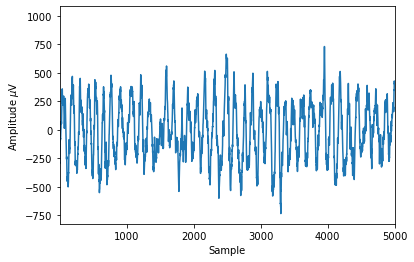

In [3]:
# Loading the REM data sent by Julien as an example to establish the method 

dataREM = scipy.io.loadmat('REM_data.mat')
lfpREM  = np.array(dataREM['REM'])
lfpREM  = lfpREM.flatten()

# Now plotting the data to inspect them
plt.plot(lfpREM)
plt.xlim((1,5000))
plt.xlabel('Sample')
plt.ylabel('Amplitude $\mu$V')
print('Procced')

Masked Sift Instantaneous Frequency Setting
[0.10697725 0.02690361 0.00809511 0.00481107 0.00173541 0.00069622]
[112.56054691  24.93847977   8.32260919   4.8223981    1.69419552
   0.65556763]
Finished section 1 in the analysis


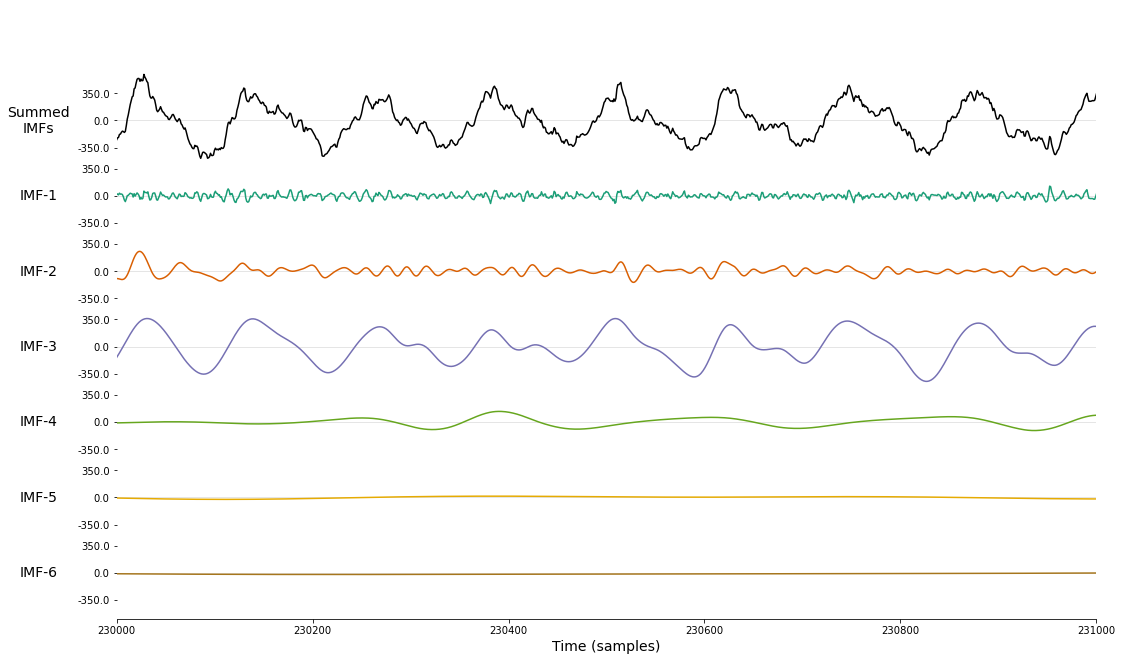

In [4]:
# Doing the EMD analysis to extract theta oscillations
print('Masked Sift Instantaneous Frequency Setting')
imf, mf =emd.sift.iterated_mask_sift(lfpREM,mask_0='if',ret_mask_freq='True')


# extract the phase, instantaneous frequency and amplitude
sample_rate = 1000
IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'hilbert', smooth_phase=3)
# you use the filtered theta signal
# we plot the results from the masked frequencies
emd.plotting.plot_imfs(imf)
plt.xlim((230000,231000))

# print the masked frequencies 
print(mf)

# print the frequency component for each imf 
A = getIMFmainfreq(IF, IA)
print(A)
print('Finished section 1 in the analysis')

(230000.0, 231000.0)

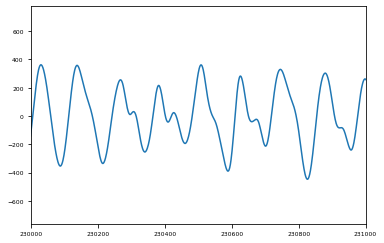

In [47]:
# First I want to know if I am chossing the correct imf component 
plt.plot(imf[:,2])
plt.xlim((230000,231000))

In [5]:
# I will continue the analysis on the thrid imf --> theta with 8 Hz frequency 
# computing the cycle characteristics 
componentI = 2

C = emd.cycles.Cycles(IP[:, componentI])
display(C)

<class 'emd.cycles.Cycles'> (3177 cycles 1 metrics) 

In [6]:
# computing the cycle metrics 
C.compute_cycle_metric('start_sample', np.arange(len(C.cycle_vect)), emd.cycles.cf_start_value)
C.compute_cycle_metric('stop_sample', imf[:, componentI], emd.cycles.cf_end_value)
C.compute_cycle_metric('peak_sample', imf[:, componentI], emd.cycles.cf_peak_sample)
C.compute_cycle_metric('desc_sample', imf[:, componentI], emd.cycles.cf_descending_zero_sample)
C.compute_cycle_metric('trough_sample', imf[:, componentI], emd.cycles.cf_trough_sample)
C.compute_cycle_metric('duration_samples', imf[:, componentI], len)

C.compute_cycle_metric('max_amp', IA[:, componentI], np.max)
C.compute_cycle_metric('mean_if', IF[:, componentI], np.mean)
C.compute_cycle_metric('max_if', IF[:, componentI], np.max)
C.compute_cycle_metric('range_if', IF[:, componentI], compute_range)

C.compute_cycle_metric('asc2desc', imf[:, componentI], asc2desc)
C.compute_cycle_metric('peak2trough', imf[:, componentI], peak2trough)

print('Finished computing the cycles metrics')

Finished computing the cycles metrics


In [95]:
display(C)

<class 'emd.cycles.Cycles'> (3177 cycles 13 metrics) 

In [7]:
# Extract subset of the cycles 
amp_thresh = np.percentile(IA[:, componentI], 25)
lo_freq_duration = sample_rate/5
hi_freq_duration = sample_rate/12
conditions = ['is_good==1',
              f'duration_samples<{lo_freq_duration}',
              f'duration_samples>{hi_freq_duration}',
              f'max_amp>{amp_thresh}']
C.pick_cycle_subset(conditions)


df = C.get_metric_dataframe(conditions=conditions)
# phase-aligned waveforms
pa, phasex = emd.cycles.phase_align(IP[:, componentI], IF[:, componentI], C.iterate(through='subset'))
# Compute normalised waveforms
norm_waveform, sine = emd.cycles.normalised_waveform(pa)
# ZC-aligned waveforms
zc_waveform = np.zeros((313, pa.shape[1]))*np.nan
zc_instfreq = np.zeros((313, pa.shape[1]))*np.nan
for ii, inds in C.iterate(through='subset'):
    zc_waveform[:len(inds), ii] = imf[inds, componentI]
    zc_instfreq[:len(inds), ii] = IF[inds, componentI]

# saving the output file
# Save output
#outfile = os.path.join(os.getcwd(), 'TrialAnalysisREM' + '.csv')
#df.to_csv(outfile)

#outfile = os.path.join(os.getcwd(), 'TrialAnalysisREM' + '.hdf5')
#out = h5py.File(outfile, 'w')

#to_save = ['imf', 'IP', 'IF', 'IA',
           #'pa', 'norm_waveform', 'zc_waveform', 'zc_instfreq']
#for key in to_save:
    #out.create_dataset(key, data=locals()[key])
#out.close()

#print('Finished the Job')

In [107]:
pa.shape

(48, 2105)

In [63]:
# this section is about calling the data --> we don't need it now since I am using
# the variables that I created directly 

datafile = os.path.join(os.getcwd(), 'TrialAnalysisREM' + '.hdf5')

F = h5py.File(datafile, 'r')
sample_rate = 1250
imf = F['imf'][...]
IP = F['IP'][...]
IA = F['IA'][...]
IF = F['IF'][...]

metricfile = os.path.join(os.getcwd(), 'TrialAnalysisREM' + '.csv')
df = pd.read_csv(metricfile)

In [97]:
# starting with some plotting and inspection of the results 
edges, bins = emd.spectra.define_hist_bins(2, 128, 128, 'log')

plot_inds = np.arange(7500+1000, 7500+1000+4*1000)

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=TINY_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=TINY_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

frames = True

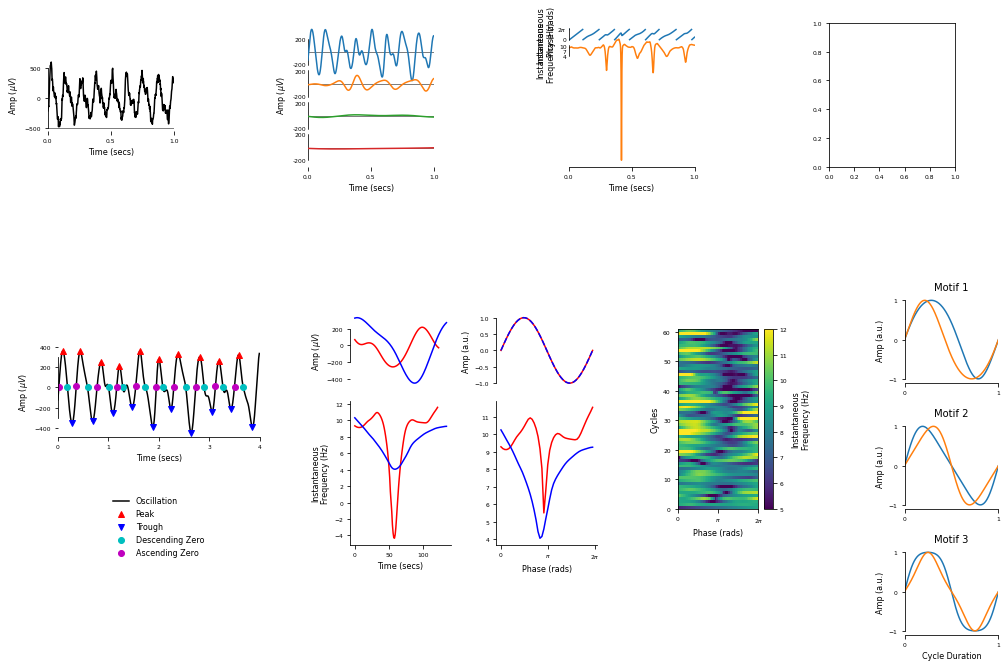

In [98]:
# plot 1
start = 230000
inds = np.arange(start, start+1000*1).astype(int)
tt = np.linspace(0, 1, len(inds))

plt.figure(figsize=(14, 10))
ax1 = plt.axes([0.05, .775, .125, .1], frameon=frames)
ax2 = plt.axes([.308, .725, .125, .2], frameon=frames)
ax3 = plt.axes([.5666, .725, .125, .2], frameon=frames)
ax4 = plt.axes([.825, .725, .125, .2], frameon=frames)
ax5 = plt.axes([.06, .35, .2, .125], frameon=frames)

ax1.plot(tt, imf[inds, :].sum(axis=1), 'k')
ax1.plot(tt, np.zeros_like(tt)-500, 'k', linewidth=0.5)
remove_frames(ax1, tags=['top', 'right', 'bottom'])
ax1.set_xlim(tt[0], tt[-1])
ax1.set_xticks([0, 0.5, 1])
ax1.set_xlabel('Time (secs)')
ax1.set_ylabel(r'Amp ($\mu V$)')
ax1.spines['left'].set_bounds(-500, 500)
ax1.set_yticks([-500, 0, 500])

remove_frames(ax2, tags=['top', 'right', 'bottom', 'left'])

ax2.set_xlim(tt[0], tt[-1])
ax2.set_xticks([0, 0.5, 1])
for ii in range(4):
    ax2.plot(tt, np.zeros_like(tt)-ii*500, 'k', linewidth=0.5)
    ax2.plot((0, 0), (-200-ii*500, 200-ii*500), 'k')
    ax2.text(-.015, 200-ii*500, '200', va='center', ha='right', fontsize=TINY_SIZE)
    ax2.text(-.015, -200-ii*500, '-200', va='center', ha='right', fontsize=TINY_SIZE)
ax2.set_yticks([])
ax2.plot(tt, imf[inds, 2:6] - np.arange(0, 2000, 500)[None, :])
ax2.set_ylabel(r'Amp ($\mu V$)', labelpad=20)
ax2.set_xlabel('Time (secs)')

ip = IP[inds, componentI]
ip[np.gradient(ip) < -2] =  np.nan
remove_frames(ax3, tags=['top', 'right', 'left'])
ax3.set_yticks([])
ax3.plot(tt, ip)
ax3.set_xlim(tt[0], tt[-1])
ax3.set_xticks([0, 0.5, 1])
ax3.set_xlabel('Time (secs)')
ax3.plot(tt, IF[inds, componentI]-14)
ax3.plot((0, 0), (0, np.pi*2), 'k')
ax3.plot((0, 0), (4-14, 10-14), 'k')
ax3.text(-.015, np.pi*2, r'2$\pi$', va='center', ha='right', fontsize=TINY_SIZE)
ax3.text(-.015, 0, r'0', va='center', ha='right', fontsize=TINY_SIZE)
ax3.text(-.015, 10-14, '10', va='center', ha='right', fontsize=TINY_SIZE)
ax3.text(-.015, 7-14, '7', va='center', ha='right', fontsize=TINY_SIZE)
ax3.text(-.015, 4-14, '4', va='center', ha='right', fontsize=TINY_SIZE)
ax3.text(-.1, 7-14, 'Instantaneous\nFrequency (Hz)', va='center', ha='right', fontsize=SMALL_SIZE, rotation=90)
ax3.text(-.1, np.pi, 'Instantaneous\nPhase (rads)', va='center', ha='right', fontsize=SMALL_SIZE, rotation=90)

#inds = np.arange(start, start+1250*4).astype(int)
#tt = np.linspace(0, 4, len(inds))
#ax4.fill_between(tt, speed[inds], 0, alpha=0.5)
#ax4.plot((tt[0], tt[-1]), (2, 2), 'k--')

#ii = imf[inds, componentI]/100 - 3.5
#ax4.plot(tt, ii, 'k')
#ii[speed[inds] > 2] = np.nan
#ax4.plot(tt, ii, 'r')
#ax4.set_xlabel('Time (secs)')
#ax4.set_xlim(tt[0], tt[-1])
#ax4.set_xticks([0, 1, 2, 3, 4])
#ax4.set_yticks([])
#remove_frames(ax4, tags=['top', 'right', 'left'])
#ax4.plot((0, 0), (0, 5), 'k')
#ax4.plot((0, 0), (-5.5, -1.5), 'k')
#ax4.text(-.03, 0, '0', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.03, 2, '2', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.03, 4, '4', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.015, -1.5, '200', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.015, -3.5, '0', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.015, -5.5, '-200', va='center', ha='right', fontsize=TINY_SIZE)
#ax4.text(-.4, -3.5, 'Amp. ($\mu$V)', va='center', ha='right', fontsize=SMALL_SIZE, rotation=90)
#ax4.text(-.4, 2.5, 'Movement\nSpeed (cm/s)', va='center', ha='right', fontsize=SMALL_SIZE, rotation=90)
inds = np.arange(start, start+1250*1).astype(int)
tt = np.linspace(0, 4, len(inds))
Cex = emd.cycles.Cycles(IP[inds, componentI], compute_timings=True)
Cex.compute_cycle_metric('peak', imf[inds, componentI], emd.cycles.cf_peak_sample)
Cex.compute_cycle_metric('desc', imf[inds, componentI], emd.cycles.cf_descending_zero_sample)
Cex.compute_cycle_metric('trough', imf[inds, componentI], emd.cycles.cf_trough_sample)
df_abs = Cex.get_metric_dataframe()


ax5.plot(imf[inds, componentI], 'k')
for ii in range(1, len(df_abs)-1):
    st = df_abs['start_sample'].values[ii]
    pk = st +  df_abs['peak'].values[ii]
    ax5.plot(pk, imf[inds[int(pk)], componentI], '^r')
    tr = st +  df_abs['trough'].values[ii]
    ax5.plot(tr, imf[inds[int(tr)], componentI], 'vb')
    asc = st +  df_abs['desc'].values[ii]
    ax5.plot(asc, imf[inds[int(asc)], componentI], 'oc')
    desc = st
    ax5.plot(desc, imf[inds[int(desc)], componentI], 'om')
    if ii == 1:
        plt.legend(['Oscillation', 'Peak', 'Trough', 'Descending Zero', 'Ascending Zero'], frameon=False, bbox_to_anchor=(0.5, -1), loc='center')
remove_frames(ax5, tags=['top', 'right'])
ax5.set_xlim(tt[0], tt[-1])
ax5.set_xticks(np.linspace(0, len(tt), 5))
ax5.set_xticklabels(np.arange(5))
ax5.set_xlabel('Time (secs)')
ax5.set_ylabel(r'Amp ($\mu V$)')
ax5.spines['left'].set_bounds(-300, 300)

ax6 = plt.axes([0.35, 0.42, 0.1, 0.1])
ax7 = plt.axes([0.35, 0.2, 0.1, 0.2])
ax8 = plt.axes([0.495, 0.42, 0.1, 0.1])
ax9 = plt.axes([0.495, 0.2, 0.1, 0.2])

pa = emd.cycles.phase_align(IP[inds, componentI], IF[inds, componentI], cycles=Cex)
cind = (3, 7)
ax6.plot(imf[inds[C._slice_cache[cind[0]]], componentI], 'r')
ax6.plot(imf[inds[C._slice_cache[cind[1]]], componentI], 'b')
remove_frames(ax6, tags=['top', 'right', 'bottom'])
ax6.set_ylabel(r'Amp ($\mu V$)')
ax6.set_xticks([])
ax6.spines['left'].set_bounds(-200, 200)

ax7.plot(IF[inds[Cex._slice_cache[cind[0]]], componentI], 'r')
ax7.plot(IF[inds[Cex._slice_cache[cind[1]]], componentI], 'b')
remove_frames(ax7, tags=['top', 'right'])
ax7.set_xlabel('Time (secs)')
ax7.set_ylabel('Instantaneous\nFrequency (Hz)', rotation=90, fontsize=SMALL_SIZE)

ax8.plot(np.sin(2*np.pi*np.linspace(0, 1)), 'r')
ax8.plot(np.sin(2*np.pi*np.linspace(0, 1)), 'b--')
remove_frames(ax8, tags=['top', 'right', 'bottom'])
ax8.set_ylabel(r'Amp (a.u.)')
ax8.set_xticks([])
ax8.spines['left'].set_bounds(-1, 1)

ax9.plot(pa[0][:, cind[0]], 'r')
ax9.plot(pa[0][:, cind[1]], 'b')
remove_frames(ax9, tags=['top', 'right'])
ax9.set_xlabel('Phase (rads)')
ax9.set_xticks(np.linspace(0, 48, 3))
ax9.set_xticklabels(['0', r'$\pi$', r'2$\pi$'])

inds = np.arange(start, start+1250*12).astype(int)
Cex2 = emd.cycles.Cycles(IP[inds, componentI], compute_timings=True)
pa, _ = emd.cycles.phase_align(IP[inds, componentI], IF[inds, componentI], cycles=Cex2)
pa = pa[:, np.isfinite(pa.mean(axis=0))]
goods = np.logical_and((pa.min(axis=0) > 3), (pa.mean(axis=0) <10))

ax10 = plt.axes([0.675, 0.25, .1, .25])
im = ax10.pcolormesh(pa[:, goods].T, vmin=5, vmax=12)
cb = plt.colorbar(im)
cb.set_label('Instantaneous\nFrequency (Hz)')
ax10.set_xlabel('Phase (rads)')
ax10.set_xticks(np.linspace(0, 48, 3))
ax10.set_xticklabels(['0', r'$\pi$', r'2$\pi$'])
ax10.set_ylabel('Cycles')

ax11 = plt.axes([0.9, 0.425, 0.093, 0.12])
ax12 = plt.axes([0.9, 0.25, 0.093, 0.12])
ax13 = plt.axes([0.9, 0.075, 0.093, 0.12])


samples_per_cycle = 480
ncycles = 6
ph = np.linspace(0, np.pi*2*ncycles, samples_per_cycle*ncycles)
t = np.linspace(0, ncycles, samples_per_cycle*ncycles)
basis = np.c_[np.zeros_like(ph),
              0.9*np.cos(2*np.pi*1*t)[:, None],
              -0.9*np.cos(2*np.pi*1*t)[:, None],
              1.55*np.sin(2*np.pi*1*t)[:, None],
              -1.55*np.sin(2*np.pi*1*t)[:, None],
              np.sin(2*np.pi*2*t)[:, None],
              -0.8*np.sin(2*np.pi*2*t)[:, None]]
basis = basis * 1/4

phs = ph[:, None] + basis

X = np.sin(phs)
IP2, IF2, IA2 = emd.spectra.frequency_transform(X, samples_per_cycle, 'hilbert')

cycles = emd.cycles.get_cycle_vector(IP2, return_good=True)

lin_inds = cycles[:, 0] == 1
inds = cycles[:, 1] == 2
ax11.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 1]))
inds = cycles[:, 2] == 2
ax11.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 2]))
remove_frames(ax11, tags=['top', 'right'])
ax11.set_yticks([-1, 0, 1])
ax11.set_ylabel('Amp (a.u.)')
ax11.set_xlim(0, 1)
ax11.set_xticks([0, 1])
ax11.set_title('Motif 1', fontsize=MEDIUM_SIZE)
ax11.spines['left'].set_bounds(-1, 1)


inds = cycles[:, 3] == 2
ax12.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 3]))
inds = cycles[:, 4] == 2
ax12.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 4]))
remove_frames(ax12, tags=['top', 'right'])
ax12.set_yticks([-1, 0, 1])
ax12.set_xlim(0, 1)
ax12.set_ylabel('Amp (a.u.)')
ax12.set_xticks([0, 1])
ax12.set_title('Motif 2', fontsize=MEDIUM_SIZE)
ax12.spines['left'].set_bounds(-1, 1)


inds = cycles[:, 5] == 2
ax13.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 5]))
inds = cycles[:, 6] == 2
ax13.plot(np.linspace(0, 1, inds.sum()), np.sin(phs[inds, 6]))
remove_frames(ax13, tags=['top', 'right'])
ax13.set_xlabel('Cycle Duration', fontsize=SMALL_SIZE)
ax13.set_yticks([-1, 0, 1])
ax13.set_ylabel('Amp (a.u.)')
ax13.set_xlim(0, 1)
ax13.set_xticks([0, 1])
ax13.set_title('Motif 3', fontsize=MEDIUM_SIZE)
ax13.spines['left'].set_bounds(-1, 1)


In [99]:
display(df_abs)
pa.shape

,is_good,start_sample,stop_sample,duration,peak,desc,trough
0,0,0,5,6,None,None,None
1,1,6,113,108,24.266679,53.233233,82.036761
2,1,114,242,129,24.114005,69.70971,101.048543
3,0,243,364,122,24.777129,71.444444,97.576556
4,0,365,482,118,16.892825,36.750751,95.719184
5,1,483,609,127,25.474198,59.561562,105.884903
6,0,610,718,109,16.001334,39.960961,91.210564
7,1,719,853,135,26.289494,73.522523,107.152151
8,1,854,976,123,25.249259,53.029029,102.573835
9,0,977,1094,118,21.11195,46.223223,96.0098


(48, 132)

Text(0, 0.5, 'Amp ($\\mu V$)')

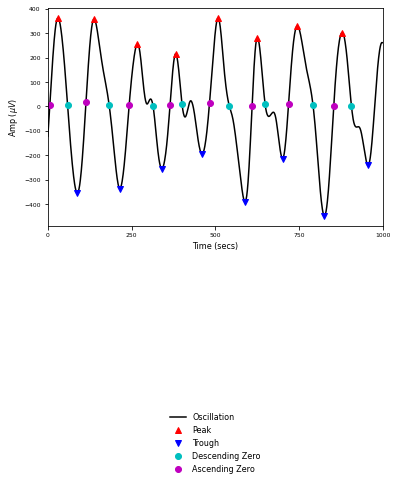

In [67]:
# I need to examine the robustness of the EMD to detect the control poiints when I
# multiple signals 
# first we plot the detected peaks and troughs based on imf2 
start = 230000
inds = np.arange(start, start+1000*1).astype(int)
tt = np.linspace(0, 1, len(inds))
IP_n, IF_n, IA_n = emd.spectra.frequency_transform(imfnew, sample_rate, 'hilbert', smooth_phase=3)

inds = np.arange(start, start+1000*1).astype(int)
tt = np.linspace(0, 4, len(inds))
Cex = emd.cycles.Cycles(IP[inds, componentI], compute_timings=True)
Cex.compute_cycle_metric('peak', imf[inds, componentI], emd.cycles.cf_peak_sample)
Cex.compute_cycle_metric('desc', imf[inds, componentI], emd.cycles.cf_descending_zero_sample)
Cex.compute_cycle_metric('trough', imf[inds, componentI], emd.cycles.cf_trough_sample)
df_abs = Cex.get_metric_dataframe()

plt.plot(imf[inds, componentI], 'k')
for ii in range(1, len(df_abs)-1):
    st = df_abs['start_sample'].values[ii]
    pk = st +  df_abs['peak'].values[ii]
    plt.plot(pk, imf[inds[int(pk)], componentI], '^r')
    tr = st +  df_abs['trough'].values[ii]
    plt.plot(tr, imf[inds[int(tr)], componentI], 'vb')
    asc = st +  df_abs['desc'].values[ii]
    plt.plot(asc, imf[inds[int(asc)], componentI], 'oc')
    desc = st
    plt.plot(desc, imf[inds[int(desc)], componentI], 'om')
    if ii == 1:
        plt.legend(['Oscillation', 'Peak', 'Trough', 'Descending Zero', 'Ascending Zero'], frameon=False, bbox_to_anchor=(0.5, -1), loc='center')
remove_frames(ax5, tags=['top', 'right'])
plt.xlim(tt[0], tt[-1])
plt.xticks(np.linspace(0, len(tt), 5))
plt.xlabel('Time (secs)')
plt.ylabel(r'Amp ($\mu V$)')



(230000.0, 231000.0)

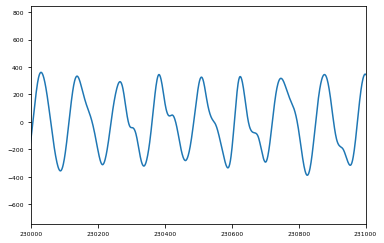

In [15]:
# combining the methods 
imfnew = imf[:,2]+imf[:,3]

plt.plot(imfnew)

plt.xlim((230000,231000))

 Checking Cycles inputs - trimming singleton from input 'IP'


Text(0.5, 1.0, 'Combined Theta Signal')

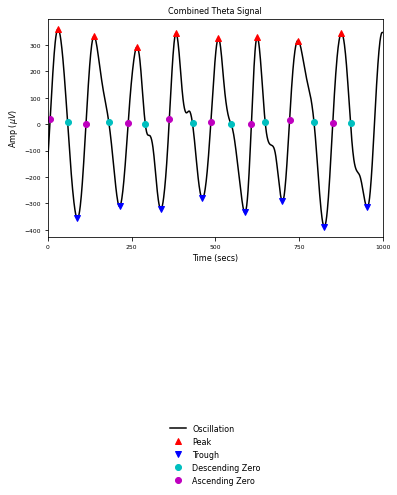

In [17]:
# testing the detection of cycles on the combined theta

start = 230000
inds = np.arange(start, start+1000*1).astype(int)
tt = np.linspace(0, 1, len(inds))
IP_n, IF_n, IA_n = emd.spectra.frequency_transform(imfnew, sample_rate, 'hilbert', smooth_phase=3)

inds = np.arange(start, start+1000*1).astype(int)
tt = np.linspace(0, 4, len(inds))
Cex_n = emd.cycles.Cycles(IP_n[inds, ], compute_timings=True)
Cex_n.compute_cycle_metric('peak', imfnew[inds, ], emd.cycles.cf_peak_sample)
Cex_n.compute_cycle_metric('desc', imfnew[inds, ], emd.cycles.cf_descending_zero_sample)
Cex_n.compute_cycle_metric('trough', imfnew[inds, ], emd.cycles.cf_trough_sample)
df_abs_n = Cex_n.get_metric_dataframe()

plt.plot(imfnew[inds, ], 'k')
for ii in range(1, len(df_abs_n)-1):
    st = df_abs_n['start_sample'].values[ii]
    pk = st +  df_abs_n['peak'].values[ii]
    plt.plot(pk, imfnew[inds[int(pk)], ], '^r')
    tr = st +  df_abs_n['trough'].values[ii]
    plt.plot(tr, imfnew[inds[int(tr)], ], 'vb')
    asc = st +  df_abs_n['desc'].values[ii]
    plt.plot(asc, imfnew[inds[int(asc)], ], 'oc')
    desc = st
    plt.plot(desc, imfnew[inds[int(desc)], ], 'om')
    if ii == 1:
        plt.legend(['Oscillation', 'Peak', 'Trough', 'Descending Zero', 'Ascending Zero'], frameon=False, bbox_to_anchor=(0.5, -1), loc='center')
remove_frames(ax5, tags=['top', 'right'])
plt.xlim(tt[0], tt[-1])
plt.xticks(np.linspace(0, len(tt), 5))
plt.xlabel('Time (secs)')
plt.ylabel(r'Amp ($\mu V$)')
plt.title('Combined Theta Signal')


In [104]:
pa.shape

(48, 132)

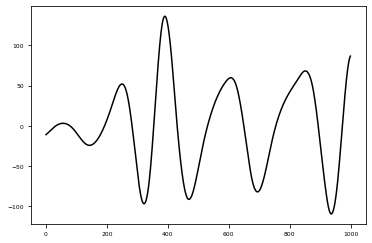

In [18]:
plt.plot(imf[inds, 3], 'k')


Text(-300, -4450.0, 'Instantaneous\nFrequency\nStd-Dev')

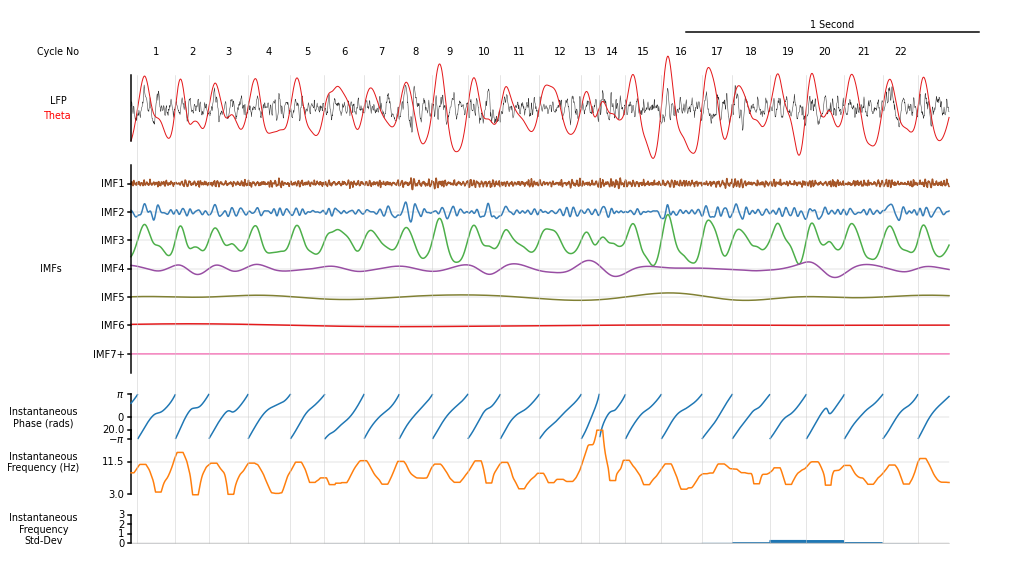

In [68]:
# creating a new figure for the analysis 
width = config['3col_width'] / 25.4
height = width * .6

plot_horiz = True
sparse_horiz = True
plot_vert = True
fontsize_side = 'large'
fontsize_tick = 10
horiz_width = .35

inds = np.arange(20230, 20000+1000*3).astype(int)
start = 193000
start = 55000
inds = np.arange(start, start+1000*2.8).astype(int)
cmap = plt.cm.Set1
cols = cmap(np.linspace(0, 1, 8))
cols[4, :] = [.5, .5, .2, 1]
indx = [5, 1, 2, 3, 4, 0, 6, 7]
cols = cols[indx, :]

plt.figure(figsize=(width*2, height*2))
plt.axes([.08, .025, .95, .95], frameon=False)
plt.xticks([])
plt.yticks([])


# making the plots 
plt.plot(imf[inds, :componentI].sum(axis=1), color=[.2, .2, .2], linewidth=.5)
plt.plot(imf[inds, componentI], color=cols[5, :], linewidth=1)
plt.plot([0, 0], [-350, 350], 'k')
plt.text(-250, 80, 'LFP', fontsize=fontsize_side,
         verticalalignment='center', horizontalalignment='center')
plt.text(-250, 600, 'Cycle No', fontsize=fontsize_side,
         verticalalignment='center', horizontalalignment='center')
plt.text(-250, -80, 'Theta', fontsize=fontsize_side,
         verticalalignment='center', horizontalalignment='center', color='r')


plt.plot([1.9*1000, 2.9*1000], [800, 800], 'k')
plt.text(2.4*1000, 825, '1 Second', horizontalalignment='center',
         verticalalignment='bottom', fontsize=fontsize_side)
# Plot IMFs
step = -500
labels = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7+']
for ii in range(7):
    yind = -300*(1+ii)+step
    if plot_horiz:
        plt.plot([-10, len(inds)], [yind, yind], color=[.7, .7, .7], linewidth=horiz_width)
    plt.plot([-10, 0], [yind, yind], 'k')
    if ii < 6:
        plt.plot(.5*imf[inds, ii]+yind, color=cols[ii, :])
    else:
        plt.plot(.5*imf[inds, ii:].sum(axis=1)+yind, color=cols[ii, :])
    plt.text(-22, yind, labels[ii], fontsize=fontsize_tick, verticalalignment='center', horizontalalignment='right')
plt.plot([0, 0], [-2800, -600], 'k')
plt.text(-275, -300*(1+3)+step, 'IMFs', fontsize=fontsize_side, verticalalignment='center', horizontalalignment='center')

# Instantaneous Phase
labels = [r'$-\pi$', r'$0$', r'$\pi$']
for ii in range(3):
    yind = -3500+ii*75*((2*np.pi)/2)
    if sparse_horiz and ii == 1:
        plt.plot([-10, len(inds)], [yind, yind], color=[.7, .7, .7], linewidth=horiz_width)
    elif plot_horiz and not sparse_horiz:
        plt.plot([-10, len(inds)], [yind, yind], color=[.7, .7, .7], linewidth=horiz_width)
    plt.plot([-10, 0], [yind, yind], color='k')
    plt.text(-22, yind, labels[ii], fontsize=fontsize_tick, verticalalignment='center', horizontalalignment='right')
plt.plot([0, 0], [-3500, -3500+2*np.pi*75], 'k')
ip = IP[inds, componentI]
naninds = np.where(np.diff(ip) < -5.5)[0]+1
ip[naninds] = np.nan
plt.plot(ip*75 - 3500, linewidth=1.5)
plt.text(-300, -3500+1*75*((2*np.pi)/2), 'Instantaneous\nPhase (rads)', fontsize=fontsize_side,
         verticalalignment='center', horizontalalignment='center')

# Instantaneous Frequency

if_to_plot =  ndimage.median_filter(IF[inds, componentI],size=40) # median filter to correct for sudden changes in phase
#if_to_plot =  IF[inds, componentI] # median filter to correct for sudden changes in phase

ymin_f = np.nanmin(np.round(if_to_plot))
ymin = np.nanmin(ymin_f*40 - 4200)
ymax_f = np.nanmax(np.round(if_to_plot))
ymax = np.nanmin(ymax_f*40 - 4200)
plt.plot([0, 0], [ymin, ymax], 'k')
indx = np.linspace(ymin, ymax, 3)
indx_f = np.linspace(ymin_f, ymax_f, 3)
for ii in range(3):
    if sparse_horiz and ii == 1:
        plt.plot([-10, len(inds)], [indx[ii], indx[ii]], color=[.7, .7, .7], linewidth=horiz_width)
    elif plot_horiz and not sparse_horiz:
        plt.plot([-10, len(inds)], [indx[ii], indx[ii]], color=[.7, .7, .7], linewidth=horiz_width)
    plt.plot([-10, 0], [indx[ii], indx[ii]], color='k')
    plt.text(-22, indx[ii], indx_f[ii], fontsize=fontsize_tick, verticalalignment='center', horizontalalignment='right')
plt.plot(if_to_plot*40 - 4200)
plt.text(-300, indx[1], 'Instantaneous\nFrequency (Hz)', fontsize=fontsize_side, verticalalignment='center', horizontalalignment='center')

# Plot cycle bounds and compute within cycle frequency variability
cycles_to_plot = emd.cycles.get_cycle_vector(IP[inds, componentI, None])
cycle_starts = np.where(np.diff(cycles_to_plot, axis=0))[0]
cm = np.zeros_like(inds)*np.nan
cv = np.zeros_like(inds)*np.nan
for ii in range(len(cycle_starts)):
    if plot_vert:
        plt.plot((cycle_starts[ii], cycle_starts[ii]), (-4600, 350), color=[.8, .8, .8], linewidth=.5)
    if ii < len(cycle_starts)-1:
        cm[cycle_starts[ii]:cycle_starts[ii+1]] = IF[inds[cycle_starts[ii]:cycle_starts[ii+1]], 5].mean()
        cv[cycle_starts[ii]:cycle_starts[ii+1]] = IF[inds[cycle_starts[ii]:cycle_starts[ii+1]], 5].std()
        plt.text((cycle_starts[ii]+cycle_starts[ii+1])/2, 600, ii+1,
                      fontsize=fontsize_tick, verticalalignment='center', horizontalalignment='center')

        # Within cycle frequency variability
plt.fill_between(np.arange(len(inds)), cv*1e2 - 4600, np.ones_like(inds)-4601)
plt.plot((0, 0), (-4601, -4601+300), 'k')
plt.plot([-15, len(inds)], (-4601, -4601), color=[.7, .7, .7], linewidth=.5)
indx = np.linspace(0, 3, 4)*1e2 - 4600
indx_lab = np.round(np.linspace(0, 3, 4), 2).astype(int)
for ii in range(4):
    if plot_horiz and sparse_horiz is False:
        plt.plot([-10, len(inds)], (indx[ii], indx[ii]), color=[.7, .7, .7], linewidth=horiz_width)
    elif  ii == 0:
        plt.plot([-10, len(inds)], (indx[ii], indx[ii]), color=[.7, .7, .7], linewidth=horiz_width)
    plt.plot((-10, 0), (-4601+100*ii, -4601+100*ii), 'k')
    plt.text(-22, indx[ii], indx_lab[ii], fontsize=fontsize_tick,
             verticalalignment='center', horizontalalignment='right')

plt.text(-300, indx[1:3].mean(), 'Instantaneous\nFrequency\nStd-Dev', fontsize=fontsize_side,
         verticalalignment='center', horizontalalignment='center')

In [108]:
# new figure and new analysis 
waveform = zc_waveform
instfreq = zc_instfreq
pa = pa
ctrl = np.c_[np.zeros_like(df['start_sample']),
             df['peak_sample'],
             df['desc_sample'],
             df['trough_sample'],
             df['duration_samples']]
ctrl_mets = np.c_[df['peak2trough'], df['asc2desc']].T

I = np.argsort(ctrl[:, 4])[::-1]

In [70]:
pa.shape
print(goods)
ctrl_mets.shape

[ True  True  True  True False False False  True  True False False  True
  True False False  True  True  True  True  True  True  True  True  True
 False  True  True False  True  True  True  True  True False False False
  True  True False False  True  True False False  True False  True  True
 False False  True  True False False False  True  True  True False  True
  True False  True  True False False False  True False False False False
 False False False  True False  True  True  True False False False False
  True False  True False False False  True  True  True False False  True
 False False  True False False False False  True False False False False
  True  True  True  True False False False False False False False  True
 False False False False False  True False False False False  True  True]


(2, 2105)

In [110]:
segments = np.zeros((ctrl.shape[0], 400))*np.nan
for ii in range(ctrl.shape[0]):
    for jj in range(1, ctrl.shape[1]):
        segments[ii, int(np.round(ctrl[ii, jj-1])):int(np.round(ctrl[ii, jj]))] = jj

# Remove cycles with ambiguous peaks
goods = np.setdiff1d(np.arange(segments.shape[0]), np.where(segments[:, 0]==4)[0])
segments = segments[goods, :]
I = np.argsort(ctrl[goods, 4])[::-1]
ctrl_mets = ctrl_mets[:, goods]
pa = pa[:,goods]
instfreq = instfreq[:, goods]
trim = 1000  # Can't see anything if we plot every cycle...
#I = I[:-trim]

/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/4268493805.py:54: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(instfreq, axis=1))


Text(0.5, 1.0, 'Instantaneous\nFrequency (Hz)')

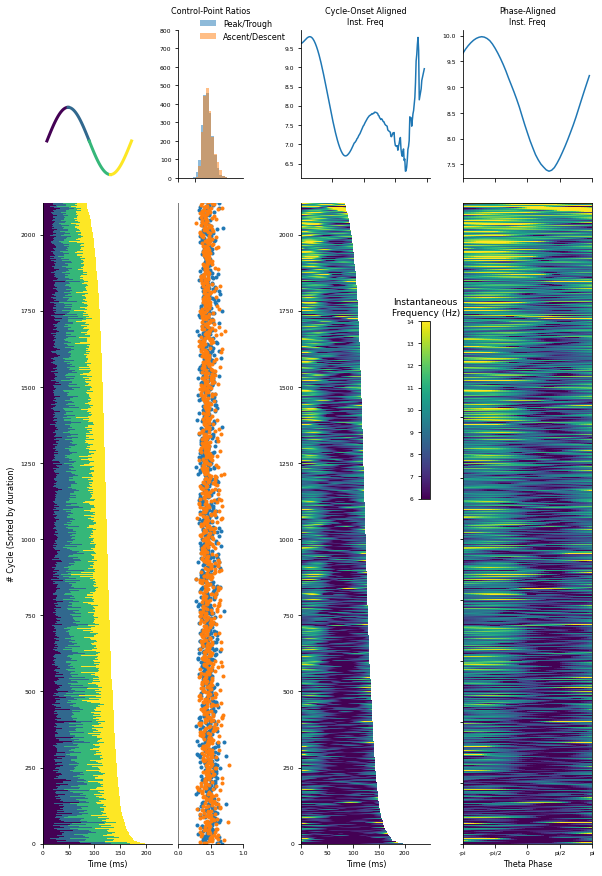

In [111]:
width = config['2col_width'] / 25.4
height = config['3col_width'] / 25.4

# Figure start
plt.figure(figsize=(width*2, height*2))

# Plot control point segments
plt.axes([.1, .1, .2, .65])
plt.pcolormesh(segments[I, :])
plt.xticks(np.linspace(0, 200, 5), (np.linspace(0, 200, 5)/sample_rate*1000).astype(int))
plt.xlabel('Time (ms)')
plt.xlim(0, 250)
plt.ylabel('# Cycle (Sorted by duration)')
decorate_ax(plt.gca())
plt.axes([.1, .775, .144, .075], frameon=False)
plt.xticks([]);
plt.yticks([])
cols = plt.cm.viridis(np.linspace(0, 1, 4))
for ii in range(4):
    xvals = np.linspace(0, .25)+.25*ii
    plt.plot(xvals, np.sin(2*np.pi*xvals), linewidth=3, color=cols[ii, :])

# Plot control point metrics
plt.axes([.31, .1, .1, .65])
plt.plot(ctrl_mets[0][I], np.arange(len(ctrl_mets[0])), '.')
plt.plot(ctrl_mets[1][I], np.arange(len(ctrl_mets[0])), '.')
plt.plot(np.zeros_like(ctrl_mets[1][I]), np.arange(len(ctrl_mets[0])), 'k', linewidth=.5)
plt.xlim(0, 1)
plt.ylim(0, len(ctrl_mets[0])-trim)
plt.yticks([])
decorate_ax(plt.gca())
plt.gca().spines['left'].set_visible(False)

plt.axes([.31, .775, .1, .15])
plt.hist(ctrl_mets[0][I], np.linspace(-1, 1), alpha=.5)
plt.hist(ctrl_mets[1][I], np.linspace(-1, 1), alpha=.5)
plt.xticks(np.linspace(-.25, .25, 3), [])
plt.legend(['Peak/Trough', 'Ascent/Descent'], frameon=False,
           fontsize=8, loc='center', bbox_to_anchor=(0.5, 0.5, 1, 1))
decorate_ax(plt.gca())
plt.xlim(0, 1)
plt.ylim(0, 800)
plt.title('Control-Point Ratios\n')

# Plot temporally aligned instantaneous frequency
plt.axes([.5, .1, .2, .65])
plt.pcolormesh(instfreq[:, I].T, vmin=6, vmax=14)
decorate_ax(plt.gca())
plt.xticks(np.linspace(0, 200, 5), (np.linspace(0, 200, 5)/sample_rate*1000).astype(int))
plt.xlabel('Time (ms)')
plt.xlim(0, 250)

plt.axes([.5, .775, .2, .15])
plt.plot(np.nanmean(instfreq, axis=1))
decorate_ax(plt.gca())
plt.title('Cycle-Onset Aligned\nInst. Freq')
plt.xticks(np.linspace(0, 200, 5), [])
plt.xlim(0.60)


# Plot phase aligned instantaneous frequency
plt.axes([.75, .1, .2, .65])
pcm = plt.pcolormesh(pa[:, I].T, vmin=6, vmax=14)
plt.xticks(np.arange(5)*12, ['-pi', '-pi/2', '0', 'pi/2', 'pi'])
plt.xlabel('Theta Phase')
plt.yticks(np.arange(8)*200, [])

plt.axes([.75, .775, .2, .15])
plt.plot(np.nanmean(pa, axis=1))
plt.xlim(0, 48)
decorate_ax(plt.gca())
plt.xticks(np.arange(5)*12, [])
plt.title('Phase-Aligned\nInst. Freq')

# Inst. freq colourbar
ax = plt.axes([.685, .45, .015, .18])
cb = plt.colorbar(pcm, cax=ax)
ax.yaxis.set_ticks_position('left')
plt.title('Instantaneous\nFrequency (Hz)', fontsize=9)


In [112]:
waveform = zc_waveform
instfreq = zc_instfreq
pa = pa
ctrl = np.c_[np.zeros_like(df['start_sample']),
             df['peak_sample'],
             df['desc_sample'],
             df['trough_sample'],
             df['duration_samples']]
ctrl_mets = np.c_[df['peak2trough'], df['asc2desc']].T

I = np.argsort(ctrl[:, 4])[::-1]
segments = np.zeros((ctrl.shape[0], 400))*np.nan
for ii in range(ctrl.shape[0]):
    for jj in range(1, ctrl.shape[1]):
        segments[ii, int(np.round(ctrl[ii, jj-1])):int(np.round(ctrl[ii, jj]))] = jj

# Remove cycles with ambiguous peaks
goods = np.setdiff1d(np.arange(segments.shape[0]), np.where(segments[:, 0]==4)[0])
segments = segments[goods, :]
I = np.argsort(ctrl[goods, 4])[::-1]
ctrl_mets = ctrl_mets[:, goods]
pa = pa
instfreq = instfreq[:, goods]
trim = 2700  # Can't see anything if we plot every cycle...
#I = I[:-trim]
I2 = I[::15]

width = config['2col_width'] / 25.4
height = config['3col_width'] / 25.4

col_height = 0.45
top_height = 0.3


/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/1926871117.py:43: RuntimeWarning: Mean of empty slice
  mn = np.nanmean(instfreq[:, I], axis=1)
/Users/abdelrahmanrayan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/1926871117.py:54: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(waveform[:, I], axis=1), 'k')


Text(0.5, 1.0, 'Instantaneous\nFrequency (Hz)\n')

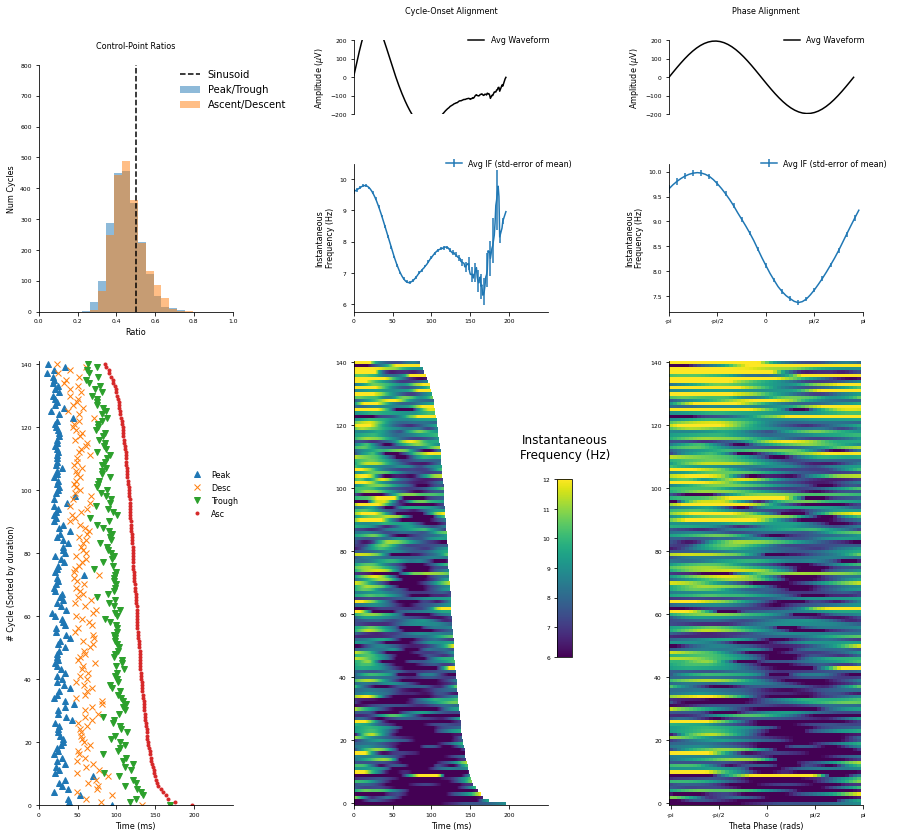

In [113]:
# Figure start
plt.figure(figsize=(width*3, height*2))

# Plot control point segments
plt.axes([.1, .1, .2, col_height])
#plt.pcolormesh(segments[I2, :])
plt.plot(ctrl[I2, 1], np.arange(len(I2)), '^')
plt.plot(ctrl[I2, 2], np.arange(len(I2)), 'x')
plt.plot(ctrl[I2, 3], np.arange(len(I2)), 'v')
plt.plot(ctrl[I2, 4], np.arange(len(I2)), '.')
plt.legend(['Peak', 'Desc', 'Trough', 'Asc'], frameon=False, loc='center', bbox_to_anchor=(0.4, 0.2, 1, 1))
plt.xticks(np.linspace(0, 200, 5), (np.linspace(0, 200, 5)/sample_rate*1000).astype(int))
plt.xlabel('Time (ms)')
plt.xlim(0, 250)
plt.ylim(0, len(I2))
plt.ylabel('# Cycle (Sorted by duration)')
decorate_ax(plt.gca())

plt.axes([.1, .6, .2, top_height-0.05])
plt.plot((0.5, 0.5), (0, 800), 'k--')
plt.hist(ctrl_mets[0][I], np.linspace(-1, 1), alpha=.5)
plt.hist(ctrl_mets[1][I], np.linspace(-1, 1), alpha=.5)
#plt.xticks(np.linspace(-.25, .25, 3))
plt.legend(['Sinusoid', 'Peak/Trough', 'Ascent/Descent'], frameon=False,
           fontsize=10, loc='center', bbox_to_anchor=(0.5, 0.4, 1, 1))
decorate_ax(plt.gca())
plt.xlim(0, 1)
plt.ylim(0, 800)
plt.title('Control-Point Ratios\n')
plt.xlabel('Ratio')
plt.ylabel('Num Cycles')


# Plot temporally aligned instantaneous frequency
plt.axes([.425, .1, .2, col_height])
plt.imshow(instfreq[:, I2].T, interpolation='nearest',  vmin=6, vmax=12, origin='lower', aspect='auto')
decorate_ax(plt.gca())
plt.xticks(np.linspace(0, 200, 5), (np.linspace(0, 200, 5)/sample_rate*1000).astype(int))
plt.xlabel('Time (ms)')
plt.xlim(0, 250)

plt.axes([.425, .6, .2, top_height/2])
mn = np.nanmean(instfreq[:, I], axis=1)
sem = np.nanstd(instfreq[:, I], axis=1)
sem = sem / np.sqrt(np.sum(np.isnan(instfreq[:, I])==False, axis=1))
plt.errorbar(np.arange(313), mn, yerr=sem, errorevery=4)
decorate_ax(plt.gca())
plt.xticks(np.linspace(0, 200, 5), (np.linspace(0, 200, 5)/sample_rate*1000).astype(int))
plt.xlim(0, 250)
plt.legend(['Avg IF (std-error of mean)'], loc='center', bbox_to_anchor=(0.3, 0.5, 1, 1), frameon=False)
plt.ylabel('Instantaneous\nFrequency (Hz)')

plt.axes([.425, .8, .2, 0.075])
plt.plot(np.nanmean(waveform[:, I], axis=1), 'k')
for tag in ['top', 'right', 'bottom']:
    plt.gca().spines[tag].set_visible(False)
plt.xticks([])
plt.ylim(-200, 200)
plt.xlim(0, 250)
plt.legend(['Avg Waveform'], loc='center', bbox_to_anchor=(0.3, 0.5, 1, 1), frameon=False)
plt.ylabel(r'Amplitude ($\mu$V)')
plt.title('Cycle-Onset Alignment\n\n')#\nInstantaneous. Frequency\n(std-error of mean)')


# Plot phase aligned instantaneous frequency
plt.axes([.75, .1, .2, col_height])
pcm = plt.imshow(pa[:, I2].T, interpolation='nearest',  vmin=6, vmax=12, origin='lower', aspect='auto')
plt.xticks(np.arange(5)*12, ['-pi', '-pi/2', '0', 'pi/2', 'pi'])
plt.xlabel('Theta Phase (rads)')
decorate_ax(plt.gca())

plt.axes([.75, .6, .2, top_height/2])
mn = np.nanmean(pa[:, I], axis=1)
sem = np.nanstd(pa[:, I], axis=1) / np.sqrt(I.shape[0])
plt.errorbar(np.arange(48), mn, yerr=sem, errorevery=2)
plt.xlim(0, 48)
decorate_ax(plt.gca())
plt.xticks(np.arange(5)*12, ['-pi', '-pi/2', '0', 'pi/2', 'pi'])
plt.ylabel('Instantaneous\nFrequency (Hz)')
plt.legend(['Avg IF (std-error of mean)'], loc='center', bbox_to_anchor=(0.3, 0.5, 1, 1), frameon=False)

plt.axes([.75, .8, .2, 0.075])
plt.plot(196*np.sin(2*np.pi*np.linspace(0, 1, 48)), 'k')
for tag in ['top', 'right', 'bottom']:
    plt.gca().spines[tag].set_visible(False)
plt.xticks([])
plt.xlim(0)
plt.ylim(-200, 200)
plt.legend(['Avg Waveform'], loc='center', bbox_to_anchor=(0.3, 0.5, 1, 1), frameon=False)
plt.ylabel(r'Amplitude ($\mu$V)')
plt.title('Phase Alignment\n\n')#\nInstantaneous. Frequency\n(std-error of mean)')

# Inst. freq colourbar
ax = plt.axes([.635, .25, .015, .18])
cb = plt.colorbar(pcm, cax=ax)
ax.yaxis.set_ticks_position('left')
plt.title('Instantaneous\nFrequency (Hz)\n', fontsize=12)

/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/921604991.py:19: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  ax1 = plt.subplot(4, 6, ind)
/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/921604991.py:20: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  ax2 = plt.subplot(4, 6, ind+1)
/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/921604991.py:21: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  ax3 = plt.subplot(4, 6, ind+2)
/var/folders/94/jzpqnvb10nscp08zry13g64h0000gn/T/ipykernel_30677/921604991.py:19: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification i

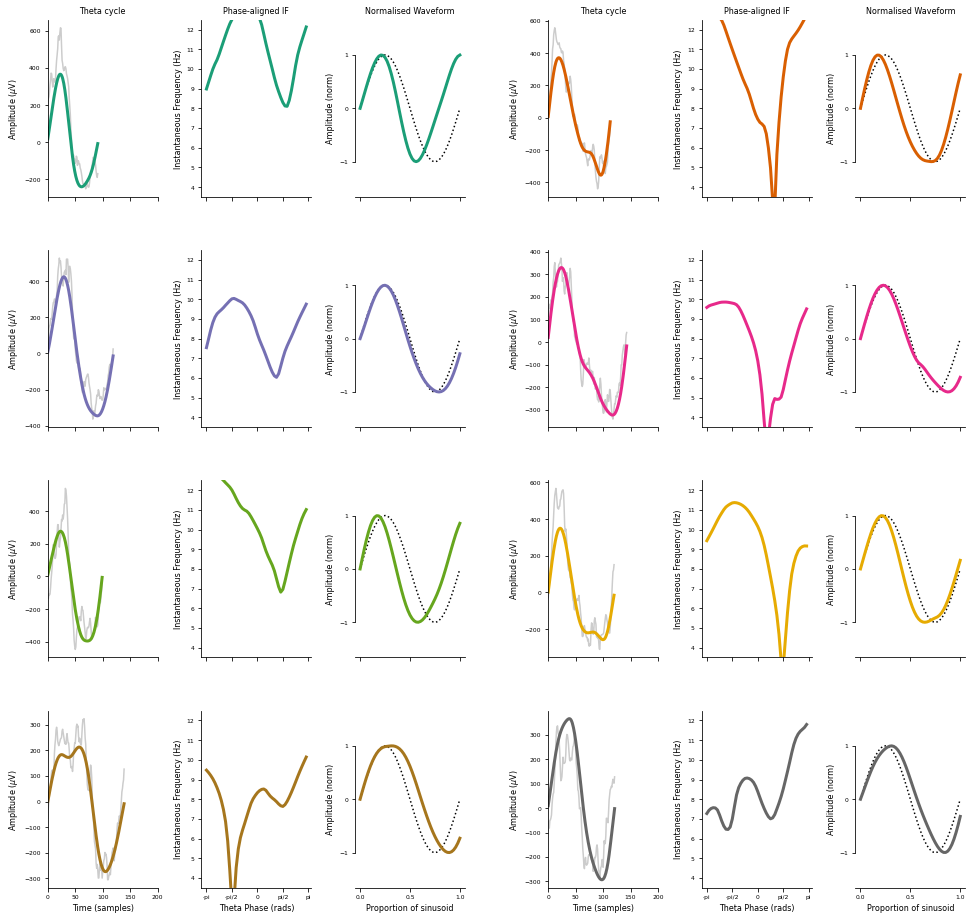

In [114]:
width = config['3col_width'] / 25.4
height = width

cycle_inds = [50, 134, 445, 897, 1103, 458, 23, 120]

cols = plt.cm.Dark2(np.linspace(0, 1, 8))
lw = 3

plt.figure(figsize=(width*2, height*2))
plt.subplots_adjust(hspace=0.3, wspace=0.4, top=0.95, bottom=0.07, right=.975, left=.085)
for ii in range(8):
    ind = np.floor(ii/2)*6 + 1
    if ii % 2 == 1:
        ind = ind + 3
        xshift = 0.01
    else:
        xshift = -0.03

    ax1 = plt.subplot(4, 6, ind)
    ax2 = plt.subplot(4, 6, ind+1)
    ax3 = plt.subplot(4, 6, ind+2)

    if ii % 2 == 1:
        shift_ax(ax1, xshift)
        shift_ax(ax2, xshift)
        shift_ax(ax3, xshift)
    else:
        shift_ax(ax3, xshift)
        shift_ax(ax2, xshift)
        shift_ax(ax1, xshift)

    start = df['start_sample'][cycle_inds[ii]]
    stop = start + df['duration_samples'][cycle_inds[ii]]
    cycle_slice = slice(start, stop)
    ax1.plot(imf[cycle_slice, :].sum(axis=1), color=[.8, .8, .8])
    ax1.plot(zc_waveform[:, cycle_inds[ii]], linewidth=lw, color=cols[ii, :])
    ax1.set_xlim(0, 200)
    ax1.set_ylabel(r'Amplitude ($\mu$V)')
    decorate(ax1, bottom_row=(ii in [6, 7]), mode='timex')
    if ii == 0 or ii == 1:
        ax1.set_title('Theta cycle')

    ax2.plot(pa[:, cycle_inds[ii]], linewidth=lw, color=cols[ii, :])
    ax2.set_ylim(3.5, 12.5)
    ax2.set_ylabel('Instantaneous Frequency (Hz)')
    decorate(ax2, bottom_row=(ii in [6, 7]), mode='phasex')
    if ii == 0 or ii == 1:
        ax2.set_title('Phase-aligned IF')

    paplot = pa[:, cycle_inds[ii]]
    sr = pa.mean() * 49
    phase = emd.spectra.phase_from_freq(paplot, sr, phase_start=0)
    phase = np.r_[0, phase]
    ax3.plot(np.sin(np.linspace(0, 2*np.pi, 49)), 'k:')
    ax3.plot(np.sin(phase), linewidth=lw, color=cols[ii, :])
    decorate(ax3, bottom_row=(ii in [6, 7]), mode='normx')
    ax3.set_ylim(-1.66, 1.66)
    ax3.set_yticks(np.linspace(-1, 1, 3))
    ax3.spines['left'].set_bounds(-1, 1)
    ax3.set_ylabel(r'Amplitude (norm)')
    if ii == 0 or ii == 1:
        ax3.set_title('Normalised Waveform')

In [8]:
pa.shape

(48, 2105)

In [9]:
# proceeding with the PCA analysis of the waveforms
imf2 = []
pa2 = []
amp = []
dur = []
speed = []
p2t = []
a2d = []


amp.append(df['max_amp'].values)
dur.append(df['duration_samples'].values)
p2t.append(df['peak2trough'].values)
a2d.append(df['asc2desc'].values)
pa2.append(pa)
imf2.append(imf)


In [11]:
pa2[0].shape

(48, 2105)

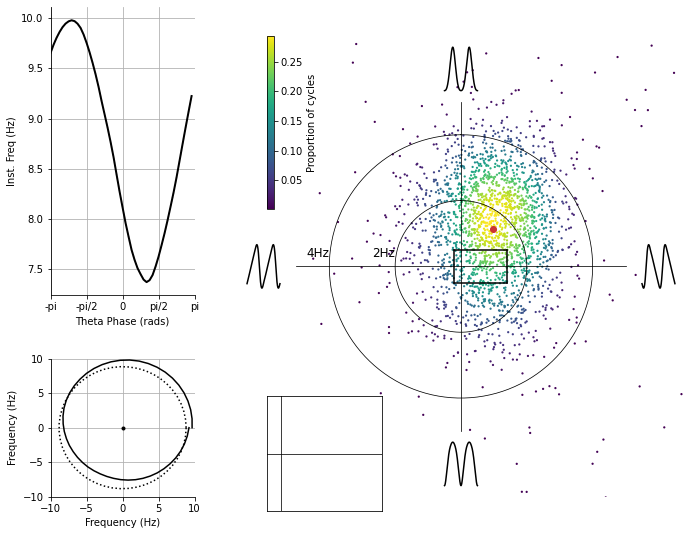

In [17]:
# creating Figure 9
plt.figure(figsize=(10, 8))
plt.axes([.1, .45, .2, .5])
linest = [':', ':', '--', '--', '-.', '-.']
run = 0
plt.plot(pa2[run].mean(axis=1), color=[.8, .8, .8], linestyle=linest[run])
plt.plot(np.concatenate(pa2, axis=1).mean(axis=1), 'k', linewidth=2)
plt.xlabel('Theta Phase (rads)')
plt.ylabel('Inst. Freq (Hz)')
plt.xticks(np.linspace(0, 48, 5), ['-pi', '-pi/2', '0', 'pi/2', 'pi'])
plt.xlim(0, 48)
for tag in ['top', 'right']:
    plt.gca().spines[tag].set_visible(False)
plt.grid(True)


plt.axes([.1, .1, .2, .24])
phi = np.cos(np.linspace(0, 2*np.pi, 48)) + 1j * np.sin(np.linspace(0, 2*np.pi, 48))
phi2 = 8.828 * phi
plt.plot(phi2.real, phi2.imag, 'k:')
phi1 = np.concatenate(pa2, axis=1).mean(axis=1) * phi
plt.plot(phi1.real, phi1.imag, 'k')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
for tag in ['top', 'right']:
    plt.gca().spines[tag].set_visible(False)
plt.plot(0, 0, 'k.')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Frequency (Hz)')
plt.grid(True)


ax = plt.axes([.35, .1, .64, .8], frameon=False)
plt.xticks([])
plt.yticks([])
mv = emd.cycles.mean_vector(np.linspace(0, 2*np.pi, 48), np.concatenate(pa2, axis=1))
scatter_kde(mv.real, mv.imag)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
add_circles(plt.gca(), waves=True, wave_height=.33)
plt.plot((-0.1, 0.7), (-0.25, -0.25), 'k')
plt.plot((-0.1, 0.7), (0.25, 0.25), 'k')
plt.plot((-0.1, -0.1), (-0.25, 0.25), 'k')
plt.plot((0.7, 0.7), (-0.25, 0.25), 'k')
plt.text(-1, 0.1, '2Hz', va='bottom', ha='right', fontsize='large')
plt.text(-2, 0.1, '4Hz', va='bottom', ha='right', fontsize='large')

mm = ['o', 'o', '+', '+', '*', '*']
mv = emd.cycles.mean_vector(np.linspace(0, 2*np.pi, 48), pa2[run].mean(axis=1)[:, None])
plt.plot(mv.real, mv.imag, mm[run], color=[0.8, .2, .2])
cbax = plt.axes([.4, .6, .01, .3])
cb = plt.colorbar(ax=ax, cax=cbax)
cb.set_label('Proportion of cycles')


ax = plt.axes([.4, 0.075, .16, .2])
add_circles(plt.gca(), waves=False, wave_height=.33)
plt.xlim(-0.1, 0.7)
plt.ylim(-0.25, 0.25)
mv = emd.cycles.mean_vector(np.linspace(0, 2*np.pi, 48), pa2[run].mean(axis=1)[:, None])
plt.plot(mv.real, mv.imag, mm[run], color=[0.8, .2, .2])

In [18]:
# Performing the PCA analysis 
# preparation of the analysis 
pc_data = np.concatenate(pa2, axis=1).T
cycle_mean = pc_data.mean(axis=1)[:, None]
phase_mean = pc_data.mean(axis=0)[:, None]
pc_data = pc_data - cycle_mean

bads, _ = sails.utils.gesd(pc_data.std(axis=1))
goods = bads == False

pca = sails.utils.PCA(pc_data[goods, :], npcs=10)

pc_proj = np.zeros((48, 2, 10))
val = 15  # PC-score to project


for ii in range(10):
    sc = np.zeros((2, 10))

    sc[0, ii] = val
    sc[1, ii] = -val
    pc_proj[:, :, ii] = pca.project_score(sc).T + phase_mean


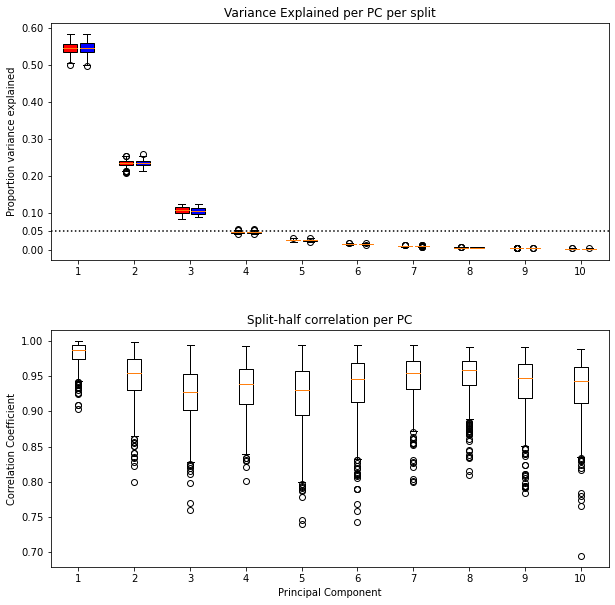

In [19]:
# running splits on the data
run_splits = True  # Default to off as this can take a minute or two

if run_splits:
    nsplits = 500
    half_ind = pc_data.shape[0]//2
    C = np.zeros((3, 10, nsplits))
    evr = np.zeros((2, 10, nsplits))
    for ii in range(nsplits):
        perm = np.random.permutation(pc_data.shape[0])

        p1 = sails.utils.PCA(pc_data[perm[:half_ind], :], npcs=10)
        p2 = sails.utils.PCA(pc_data[perm[-half_ind:], :], npcs=10)

        evr[0, :, ii] = p1.explained_variance_ratio
        evr[1, :, ii] = p2.explained_variance_ratio

        for jj in range(10):

            C[0, jj, ii] = np.corrcoef(pca.components[jj, :], p1.components[jj, :])[0, 1]
            C[1, jj, ii] = np.corrcoef(pca.components[jj, :], p2.components[jj, :])[0, 1]
            C[2, jj, ii] = np.corrcoef(p1.components[jj, :], p2.components[jj, :])[0, 1]
    C = np.abs(C)

    plt.figure(figsize=(10, 10))
    plt.subplots_adjust(hspace=0.3)
    plt.subplot(211)
    h1 = plt.boxplot(evr[0, :, :].T, positions=2*np.arange(10)-0.3, patch_artist=True)
    h2 = plt.boxplot(evr[1, :, :].T, positions=2*np.arange(10)+0.3, patch_artist=True)
    plt.xlim(-1, 19)
    plt.plot((-1, 19), (0.05, 0.05), 'k:')
    plt.yticks([0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    plt.xticks(np.arange(10)*2, np.arange(1, 11))
    for ii in range(len(h1['boxes'])):
        h1['boxes'][ii].set_facecolor('red')
        h2['boxes'][ii].set_facecolor('blue')
    plt.title('Variance Explained per PC per split')
    plt.ylabel('Proportion variance explained')
    plt.subplot(212)
    plt.boxplot(C[2, :, :].T, positions=2*np.arange(10))
    plt.xticks(np.arange(10)*2, np.arange(1, 11))
    plt.xlim(-1, 19)
    plt.title('Split-half correlation per PC')
    plt.ylabel('Correlation Coefficient')
    plt.xlabel('Principal Component')
    


In [20]:
# compute a GLM model of the waveforms 
shape_glm_config = """
first_level:
  regressors:
    - {name: Mean,        rtype: ConstantRegressor }
    - {name: Duration,    rtype: ParametricRegressor,
                          datainfo: duration, preproc: z }
    - {name: Amplitude ,  rtype: ParametricRegressor,
                          datainfo: amplitude, preproc: z }
  contrasts:
    - {name: Mean,         values: 1 0 0}
    - {name: Duration,     values: 0 1 0}
    - {name: Amplitude,    values: 0 0 1}
"""

glmdata = np.concatenate((pca.scores, np.hstack(p2t)[goods, None], np.hstack(a2d)[goods, None]), axis=1)
data = glm.data.TrialGLMData(data=glmdata,
                             amplitude=np.concatenate(amp)[goods],
                             duration=np.concatenate(dur)[goods])


In [29]:
DC = glm.design.DesignConfig(yaml_text=shape_glm_config)
des = DC.design_from_datainfo(data.info)


model = glm.fit.OLSModel(des, data)

perms = [glm.permutations.Permutation(des, data, ind, 500, metric='tstats', nprocesses=6) for ind in range(1, 3)]


tstats = model.tstats[1:, :4]
thresh = np.zeros((2, 4))  # Three predictors and four components
thresh2 = np.zeros((2, 4))  # Three predictors and four components
for ii in range(2):
    thresh[ii, :] = perms[ii].get_thresh(99)[:4]
    thresh2[ii, :] = perms[ii].get_thresh(99.9)[:4]
is_sig = np.abs(tstats) > thresh
is_sig2 = np.abs(tstats) > thresh2


Permuting contrast <class 'glmtools.design.Contrast'>(Duration,MainEffect) with mode=row-shuffle
	Computing 500 permutations
Permuting contrast <class 'glmtools.design.Contrast'>(Amplitude,MainEffect) with mode=row-shuffle
	Computing 500 permutations


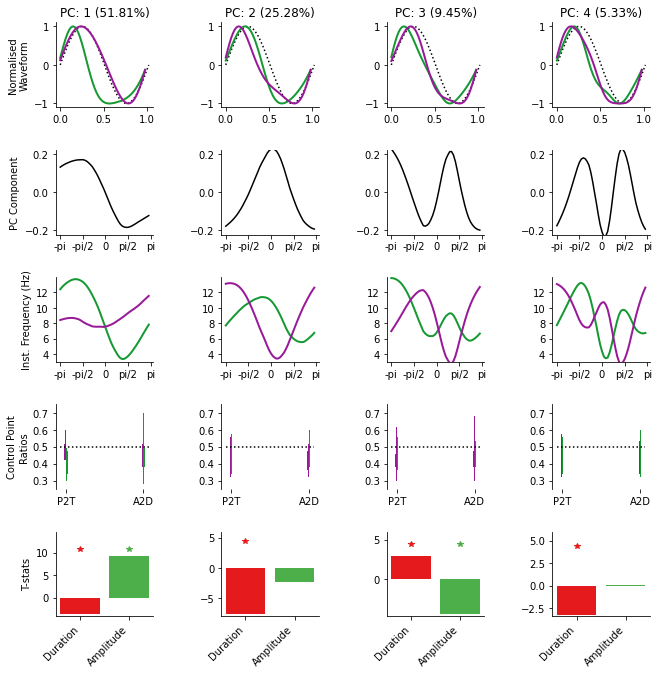

In [37]:
# creating figure 10
col1 = [0.085, 0.6, 0.201]  # Green
col2 = [.6, .1, .6]  # Fuchsia

col_centre = [0.865, 0.865, 0.865]  # Grey

R = np.interp(np.linspace(-1, 1), [-1, 0, 1], [col1[0], col_centre[0], col2[0]])
G = np.interp(np.linspace(-1, 1), [-1, 0, 1], [col1[1], col_centre[1], col2[1]])
B = np.interp(np.linspace(-1, 1), [-1, 0, 1], [col1[2], col_centre[2], col2[2]])
A = np.ones_like(R)

GrFu = ListedColormap(np.c_[R, G, B, A], name='GrFu')
cmap = GrFu(np.linspace(0, 1, 128))
barcol = plt.cm.Set1(np.linspace(0, 1, 5))

plt.figure(figsize=(10, 10))
plt.subplots_adjust(top=0.95, right=0.95, hspace=0.5, wspace=0.7)

for ii in range(4):
    plt.subplot(5, 4, ii+1)
    plt.plot(np.sin(np.linspace(0, 2*np.pi)), 'k:')
    sr = pc_proj[:, 0, ii].mean() * 49
    phase = emd.spectra.phase_from_freq(pc_proj[:, 0, ii], sr, phase_start=0)
    plt.plot(np.sin(phase), color=col1, linewidth=2)
    sr = pc_proj[:, 1, ii].mean() * 49
    phase = emd.spectra.phase_from_freq(pc_proj[:, 1, ii], sr, phase_start=0)
    plt.plot(np.sin(phase), color=col2, linewidth=2)
    for tag in ['top', 'right']:
        plt.gca().spines[tag].set_visible(False)
    plt.gca().spines[tag].set_bounds(-1, 1)
    if ii == 0:
        plt.ylabel('Normalised\nWaveform')
    plt.xticks(np.linspace(0, 48, 3), np.linspace(0, 1, 3))
    plt.title('PC: {0} ({1}%)'.format(ii+1, np.round(pca.explained_variance_ratio[ii]*100, 2)))
    
    plt.subplot(5, 4, ii+5)
    plt.plot(pca.components[ii, :], 'k', linewidth=1.5)
    plt.ylim(-.225, .225)
    for tag in ['top', 'right']:
        plt.gca().spines[tag].set_visible(False)
    if ii == 0:
        plt.ylabel('PC Component')
    plt.xticks(np.linspace(0, 48, 5), ['-pi', '-pi/2', '0', 'pi/2', 'pi'])

    plt.subplot(5, 4, ii+9)
    plt.plot(pc_proj[:, 0, ii], color=col1, linewidth=2)
    plt.plot(pc_proj[:, 1, ii], color=col2, linewidth=2)
    for tag in ['top', 'right']:
        plt.gca().spines[tag].set_visible(False)
    plt.ylim(3, 14)
    plt.yticks(np.arange(4, 14, 2))
    if ii == 0:
        plt.ylabel('Inst. Frequency (Hz)')
    plt.xticks(np.linspace(0, 48, 5), ['-pi', '-pi/2', '0', 'pi/2', 'pi'])
    plt.subplot(5, 4, ii+13)
    d = [data.data[pca.scores[:, ii] > 0, 10], data.data[pca.scores[:, ii] < 0, 10],
         data.data[pca.scores[:, ii] > 0, 11], data.data[pca.scores[:, ii] < 0, 11]]
    h1 = np.histogram(d[0], np.linspace(0, 1))
    h2 = np.histogram(d[1], np.linspace(0, 1))
    
    
    plt.barh(h1[1][:-1] + np.abs(np.diff(h1[1]))/2, h1[0]/2, align='center', height=0.07231023, color=col1)
    plt.barh(h2[1][:-1] + np.abs(np.diff(h2[1]))/2, -h2[0]/2, align='center', height=0.07231023, color=col2)

    h1 = np.histogram(d[2], np.linspace(0, 1))
    h2 = np.histogram(d[3], np.linspace(0, 1))

    plt.barh(h1[1][:-1] + np.abs(np.diff(h1[1]))/2, h1[0]/2, align='center', height=0.07231023, left=4000, color=col1)
    plt.barh(h2[1][:-1] + np.abs(np.diff(h2[1]))/2, -h2[0]/2, align='center', height=0.07231023, left=4000, color=col2)
    plt.ylim(.25, .75)
    plt.yticks(np.arange(0.3, 0.8, 0.1))
    plt.plot(plt.gca().get_xlim(), [0.5, 0.5], 'k:')
    plt.xticks([0, 4000], ['P2T', 'A2D'])
    for tag in ['top', 'right', 'bottom']:
        plt.gca().spines[tag].set_visible(False)
    if ii == 0:
        plt.ylabel('Control Point\nRatios')
    plt.subplot(5, 4, ii+17)
    h = plt.bar(np.arange(2), model.tstats[1:, ii], color=barcol[:4, :])
    plt.xticks(np.arange(2), model.contrast_names[1:], rotation=45, ha="right")
    for tag in ['top', 'right']:
        plt.gca().spines[tag].set_visible(False)
    if ii == 0:
        plt.ylabel('T-stats')
    yl = plt.ylim()
    yy = np.max([yl[1], 4])
    for jj in range(2):
        if is_sig[jj, ii]:
            plt.plot(jj, yy*1.1, '*', color=barcol[jj, :])
    plt.ylim(yl[0], yy*1.5)
